<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/39_random_forest_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Hyperparameter Tuning

In this notebook, we explore how Random Forest performance changes with different hyperparameter values.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    random_state=42
)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
results = []

In [5]:
for trees in [10, 50, 100, 200]:

    rf = RandomForestClassifier(
        n_estimators=trees,
        random_state=42
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    results.append(
        [trees, acc]
    )

In [6]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Number of Trees",
        "Accuracy"
    ]
)

comparison

,Number of Trees,Accuracy
0,10,0.89
1,50,0.92
2,100,0.92
3,200,0.94


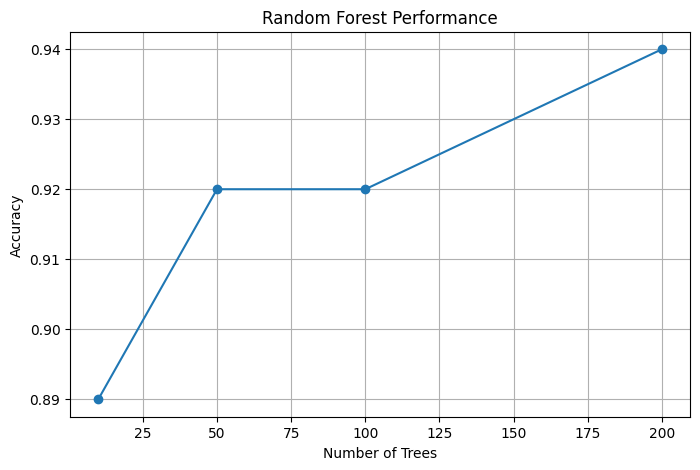

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    comparison["Number of Trees"],
    comparison["Accuracy"],
    marker='o'
)

plt.xlabel("Number of Trees")

plt.ylabel("Accuracy")

plt.title(
    "Random Forest Performance"
)

plt.grid()

plt.show()

In [8]:
depth_results = []

In [9]:
for depth in [2, 4, 6, 8, None]:

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    depth_results.append(
        [str(depth), acc]
    )

In [10]:
depth_df = pd.DataFrame(
    depth_results,
    columns=[
        "Max Depth",
        "Accuracy"
    ]
)

depth_df

,Max Depth,Accuracy
0,2,0.83
1,4,0.87
2,6,0.93
3,8,0.92
4,None,0.92


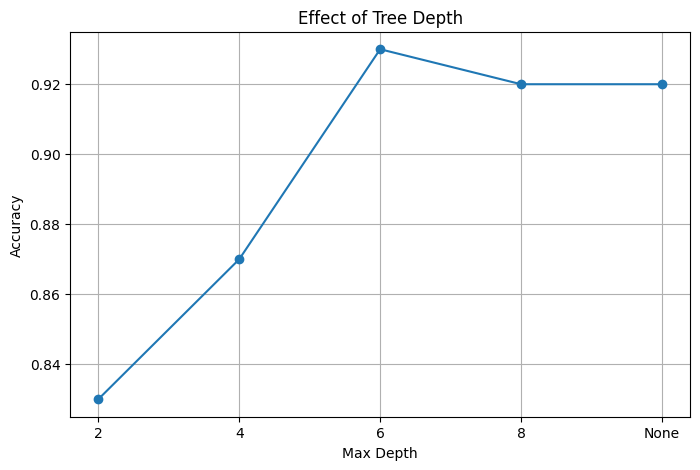

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    depth_df["Max Depth"],
    depth_df["Accuracy"],
    marker='o'
)

plt.xlabel("Max Depth")

plt.ylabel("Accuracy")

plt.title(
    "Effect of Tree Depth"
)

plt.grid()

plt.show()

## Conclusion

Random Forest performance depends on hyperparameter selection.

Observations:
- Increasing the number of trees often improves stability.
- More trees do not always guarantee significantly higher accuracy.
- Tree depth affects model complexity.
- Hyperparameter tuning helps balance performance and generalization.